## Setup

In [1]:
# Set project root to ChessClassification

import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
if project_root not in sys.path:
    sys.path.append(project_root)

print(f"Project root added to path: {project_root}")

Project root added to path: /home/zmoraj/ChessClassification


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from torchvision import transforms, models
from src.network.training import train
from src.network.evaluation import evaluate, analyze_model_performance, evaluate_with_solver, analyze_model_performance_solver
from src.preprocessing.dataset import ChessBoardDataset
from src.utils.dataset_utils import calculate_stats, build_transforms
from src.utils.plotting import visualize_test_samples, visualize_test_samples_with_solver, plot_training_history
from src.constants import CLASS_MAP

In [3]:
# Load data 

TRAIN_DATA_ROOT = os.path.join(project_root, "data/train/synthetic")
VAL_DATA_ROOT = os.path.join(project_root, "data/validation/synthetic")
TEST_REAL_DATA_ROOT = os.path.join(project_root, "data/test/real")
BATCH_SIZE = 2
NUM_WORKERS = 4
SIZE = 112

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

# Compute statistics
train_mean, train_std, test_mean, test_std = calculate_stats(TRAIN_DATA_ROOT, TEST_REAL_DATA_ROOT, SIZE, SIZE, NUM_WORKERS)

# Build final datasets and DataLoaders
baseline_config = {} 
train_transform = build_transforms(train_mean, train_std, config=baseline_config)
test_transform = build_transforms(test_mean, test_std, config=baseline_config)

train_dataset = ChessBoardDataset(root_dir=TRAIN_DATA_ROOT, transform=train_transform, padding=1.0)
val_dataset = ChessBoardDataset(root_dir=VAL_DATA_ROOT, transform=train_transform, padding=1.0)
test_real_dataset = ChessBoardDataset(root_dir=TEST_REAL_DATA_ROOT, transform=test_transform, padding=1.0)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_real_loader = DataLoader(test_real_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

device: cuda
Training samples: 1800 | Test samples: 205
Computing mean and std for training data...


Calculating Stats: 100%|██████████| 113/113 [00:32<00:00,  3.43it/s]



Calculated training mean: [0.7266303300857544, 0.6799918413162231, 0.5675383806228638]
Calculated training std:  [0.08976191282272339, 0.09742976725101471, 0.08831595629453659]

Computing mean and std for test data...


Calculating Stats: 100%|██████████| 13/13 [00:04<00:00,  3.21it/s]


Calculated test mean: [0.7061654329299927, 0.6712028980255127, 0.5853357911109924]
Calculated test std:  [0.13416209816932678, 0.14039230346679688, 0.1279790848493576]



In [4]:
# Define ConvNext-Tiny model

def get_convnext_model(num_classes=13):
    model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
    
    # Replace final FC layer
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)
    
    return model

In [5]:
# Initialize model

model = get_convnext_model().to(device)

print("\nModel Initialized: ConvNext-Tiny (Pretrained)")
print(f"Output classes: {model.classifier[2].out_features}")


Model Initialized: ConvNext-Tiny (Pretrained)
Output classes: 13


## Training

Training on cuda for 5 epochs...


Training Progress:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1/5 | Train: Loss=0.0597 Acc=0.9841  Val: Loss=0.0046 Acc=0.9986   [Saved Best]
Epoch 2/5 | Train: Loss=0.0061 Acc=0.9988  Val: Loss=0.0138 Acc=0.9971  
Epoch 3/5 | Train: Loss=0.0044 Acc=0.9993  Val: Loss=0.0018 Acc=0.9995   [Saved Best]
Epoch 4/5 | Train: Loss=0.0028 Acc=0.9995  Val: Loss=0.0029 Acc=0.9998   [Saved Best]
Epoch 5/5 | Train: Loss=0.0018 Acc=0.9997  Val: Loss=0.0009 Acc=0.9999   [Saved Best]

Training complete in 71m 41s
Best Val Acc: 0.9999


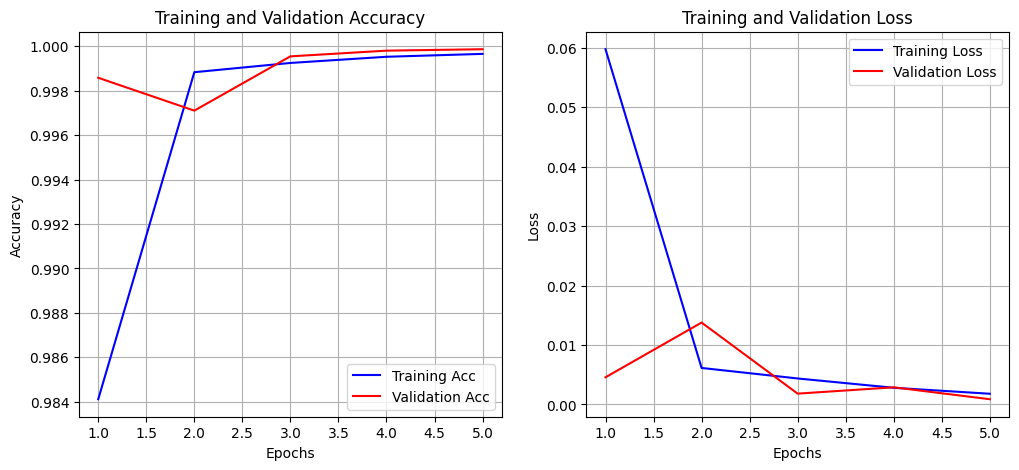

In [6]:
# Training loop

# Configuration
lr = 1e-4
num_epochs = 5
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-5)

# Training
best_model, history = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=num_epochs,
    device=device,
    save_path=os.path.join(project_root, 'models/convnext_new_data.pth')
)

# Plotting train and validation statistics
plot_training_history(history)

## Evaluation

In [7]:
# Evaluation on real test data

test_real_dataset.return_fen = False
square_acc, board_acc = evaluate(best_model, test_real_loader, device)

print(f"Square accuracy: {square_acc:.2f}")
print(f"Board accuracy: {board_acc:.2f}")

Starting Evaluation on 205 boards...


Evaluating:   0%|          | 0/103 [00:00<?, ?it/s]

Square accuracy: 84.78
Board accuracy: 0.00


In [8]:
# Evaluation with solver on real test data

test_real_dataset.return_fen = False
square_acc, board_acc = evaluate_with_solver(best_model, test_real_loader, device)

print(f"Square accuracy: {square_acc:.2f}")
print(f"Board accuracy: {board_acc:.2f}")

Starting Solver Evaluation on 205 boards...


Solver Inference:   0%|          | 0/103 [00:00<?, ?it/s]

Square accuracy: 86.86
Board accuracy: 0.00


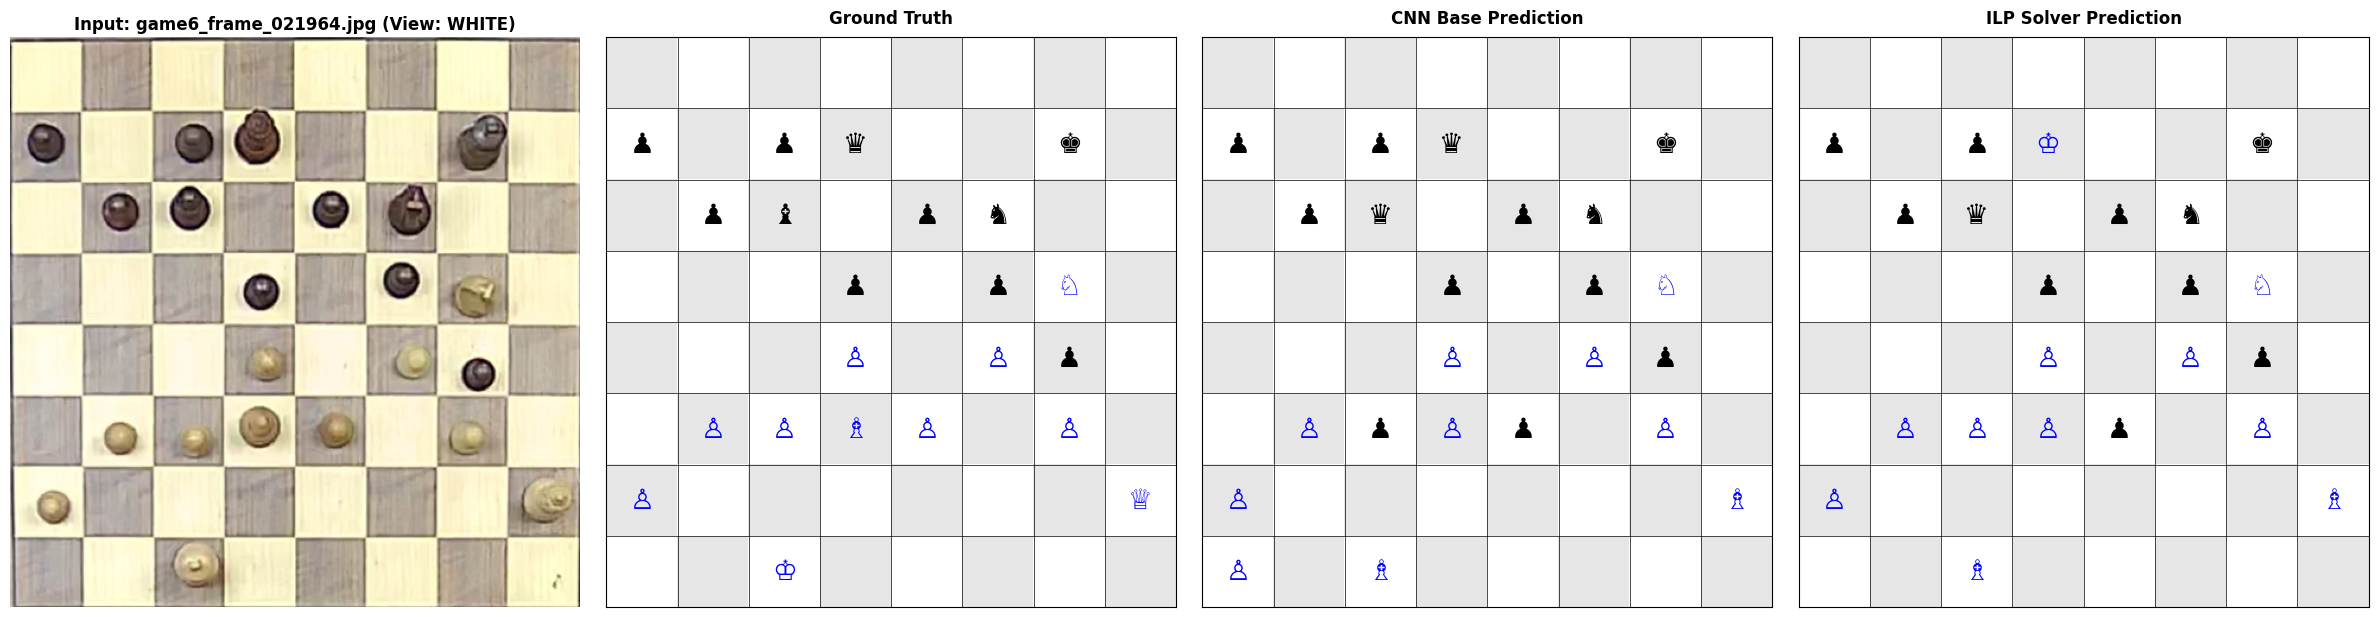

True FEN:   8/p1pq2k1/1pb1pn2/3p1pN1/3P1Pp1/1PPBP1P1/P6Q/2K5
CNN FEN:    8/p1pq2k1/1pq1pn2/3p1pN1/3P1Pp1/1PpPp1P1/P6B/P1B5
Solver FEN: 8/p1pK2k1/1pq1pn2/3p1pN1/3P1Pp1/1PPPp1P1/P6B/2B5
MISMATCH ON BOTH



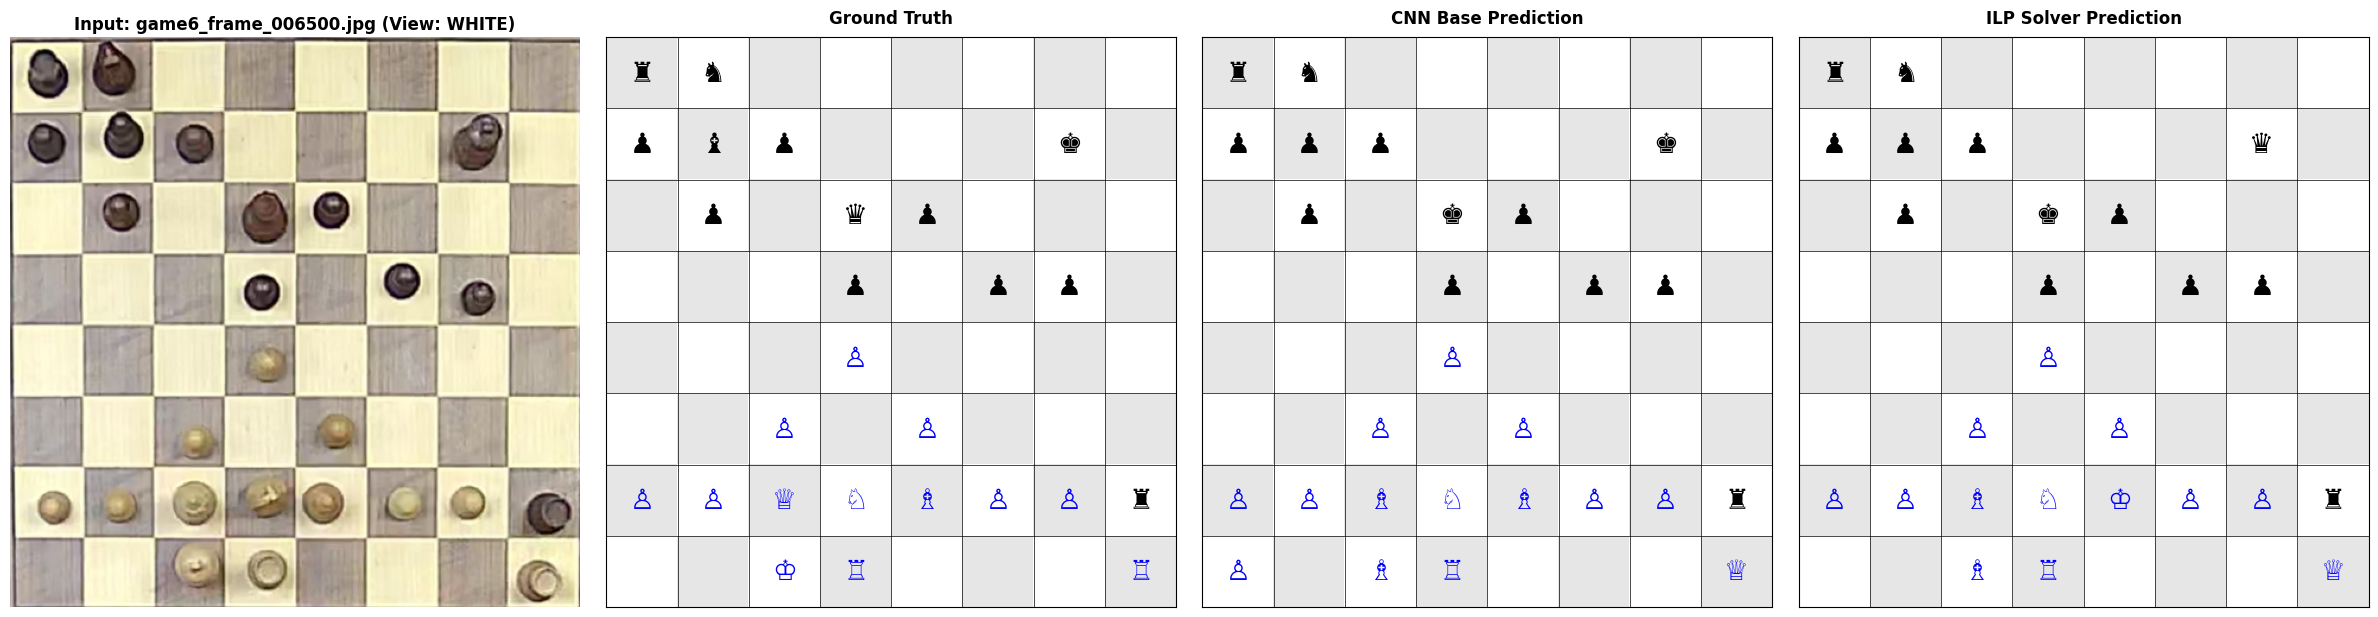

True FEN:   rn6/pbp3k1/1p1qp3/3p1pp1/3P4/2P1P3/PPQNBPPr/2KR3R
CNN FEN:    rn6/ppp3k1/1p1kp3/3p1pp1/3P4/2P1P3/PPBNBPPr/P1BR3Q
Solver FEN: rn6/ppp3q1/1p1kp3/3p1pp1/3P4/2P1P3/PPBNKPPr/2BR3Q
MISMATCH ON BOTH



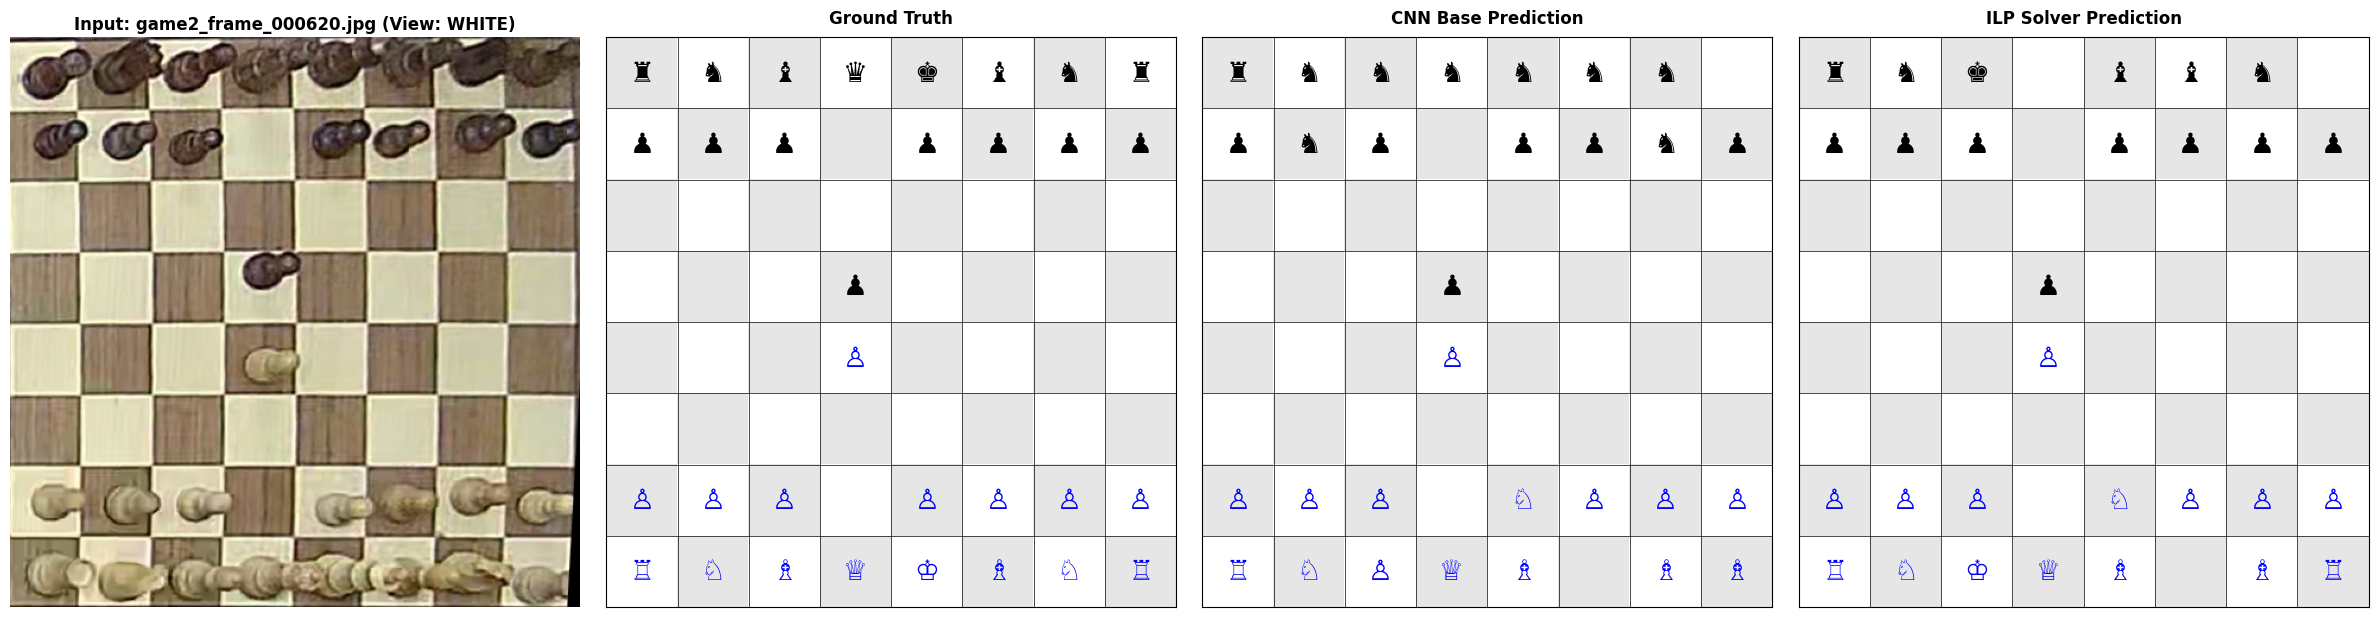

True FEN:   rnbqkbnr/ppp1pppp/8/3p4/3P4/8/PPP1PPPP/RNBQKBNR
CNN FEN:    rnnnnnn1/pnp1ppnp/8/3p4/3P4/8/PPP1NPPP/RNPQB1BB
Solver FEN: rnk1bbn1/ppp1pppp/8/3p4/3P4/8/PPP1NPPP/RNKQB1BR
MISMATCH ON BOTH



In [9]:
# Visualizing base model outputs and solver outputs

test_real_dataset.return_fen = True
visualize_test_samples_with_solver(best_model, test_real_dataset, num_samples=3, device=device)

Solver Inference:   0%|          | 0/103 [00:00<?, ?it/s]

Accuracy per Class:

white_pawn: 82.32% (1164/1414 correct)
white_rook: 52.71% (146/277 correct)
white_knight: 70.35% (159/226 correct)
white_bishop: 33.59% (86/256 correct)
white_queen: 1.75% (3/171 correct)
white_king: 17.56% (36/205 correct)
black_pawn: 86.23% (1209/1402 correct)
black_rook: 83.05% (245/295 correct)
black_knight: 81.22% (186/229 correct)
black_bishop: 27.13% (67/247 correct)
black_queen: 38.82% (66/170 correct)
black_king: 44.88% (92/205 correct)
empty     : 98.93% (7937/8023 correct)




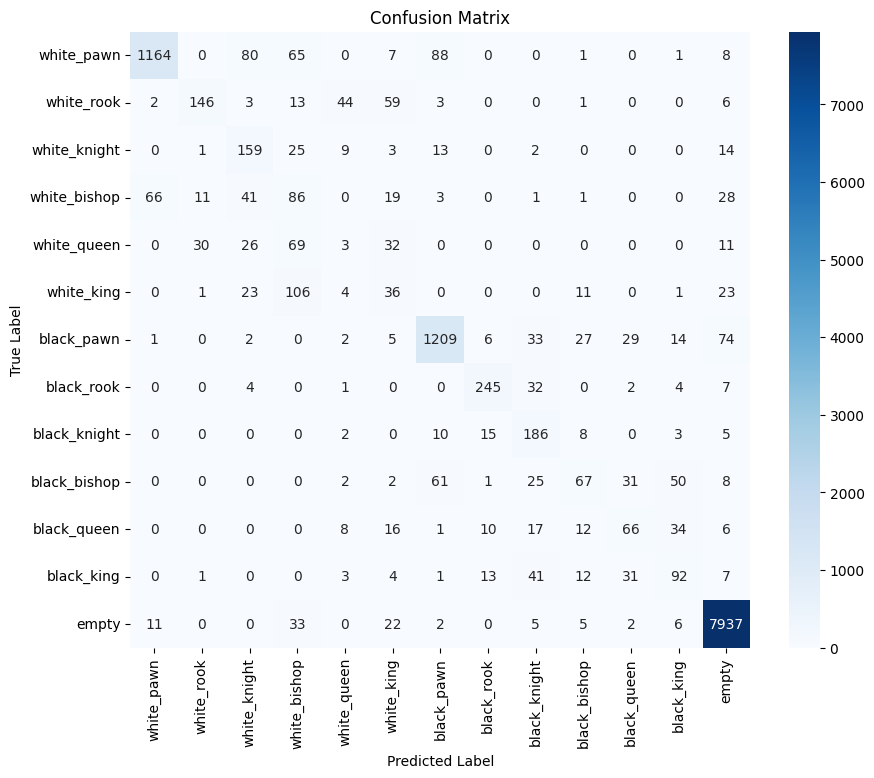

In [11]:
# Analyzing model with solver outputs and performance

class_names = list(CLASS_MAP.keys())
test_real_dataset.return_fen = False
analyze_model_performance_solver(best_model, test_real_loader, class_names, device)